# Trực quan kết quả `generated_qa_30`

Notebook này đọc 8 luồng benchmark RAG trong `results/generated_qa_30`, gồm file raw `qwen...json` và file chấm `eval_qwen...json`.

Các biểu đồ chính:
- Bảng tổng hợp điểm từng luồng
- Biểu đồ `pass_rate`, `retrieval_hit_rate`, `answer_keyword_hit_rate`, `answer_product_name_hit_rate`
- Latency trung bình
- Danh sách câu sai để phân tích lỗi


In [1]:
from pathlib import Path
import glob
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 180)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent

RESULT_DIR = ROOT / 'results' / 'generated_qa_30'
QUESTION_PATH = ROOT / 'data' / 'eval' / 'generated_qa_30.json'

print('ROOT:', ROOT)
print('RESULT_DIR:', RESULT_DIR)
print('QUESTION_PATH:', QUESTION_PATH)
assert RESULT_DIR.exists(), f'Không thấy thư mục {RESULT_DIR}'
assert QUESTION_PATH.exists(), f'Không thấy file {QUESTION_PATH}'


ROOT: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep
RESULT_DIR: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep/results/generated_qa_30
QUESTION_PATH: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep/data/eval/generated_qa_30.json


In [2]:
def parse_pipeline_name(path):
    name = Path(path).stem
    is_eval = name.startswith('eval_')
    if is_eval:
        name = name[len('eval_'):]
    llm, embedding = name.split('__', 1)
    return llm, embedding

questions = json.loads(QUESTION_PATH.read_text(encoding='utf-8'))
questions_df = pd.DataFrame(questions)

eval_rows = []
for path in sorted(RESULT_DIR.glob('eval_*.json')):
    report = json.loads(path.read_text(encoding='utf-8'))
    llm, embedding = parse_pipeline_name(path)
    row = {'llm': llm, 'embedding': embedding, 'pipeline': f'{llm} + {embedding}', 'eval_file': path.name}
    row.update(report['summary'])
    eval_rows.append(row)

summary_df = pd.DataFrame(eval_rows).sort_values(['pass_rate', 'retrieval_hit_rate'], ascending=False)
for col in ['pass_rate', 'retrieval_hit_rate', 'answer_keyword_hit_rate', 'answer_product_name_hit_rate']:
    summary_df[col + '_pct'] = (summary_df[col] * 100).round(2)

summary_df[['pipeline', 'total', 'passed', 'pass_rate_pct', 'retrieval_hit_rate_pct', 'answer_keyword_hit_rate_pct', 'answer_product_name_hit_rate_pct']]


,pipeline,total,passed,pass_rate_pct,retrieval_hit_rate_pct,answer_keyword_hit_rate_pct,answer_product_name_hit_rate_pct
4,qwen3_4b + bge_m3,30,28,93.33,93.33,96.67,93.33
0,qwen25_3b + bge_m3,30,26,86.67,93.33,90.00,86.67
5,qwen3_4b + multilingual_e5_base,30,22,73.33,73.33,93.33,83.33
1,qwen25_3b + multilingual_e5_base,30,20,66.67,73.33,83.33,73.33
7,qwen3_4b + vietnamese_bi_encoder,30,12,40.00,40.00,80.00,76.67
3,qwen25_3b + vietnamese_bi_encoder,30,11,36.67,40.00,80.00,70.00
2,qwen25_3b + sup_simcse,30,4,13.33,13.33,86.67,73.33
6,qwen3_4b + sup_simcse,30,4,13.33,13.33,83.33,76.67


In [3]:
display(summary_df[['pipeline', 'total', 'passed', 'pass_rate_pct', 'retrieval_hit_rate_pct', 'answer_keyword_hit_rate_pct', 'answer_product_name_hit_rate_pct']])

best = summary_df.iloc[0]
print('Luồng tốt nhất:', best['pipeline'])
print('Pass rate:', f"{best['pass_rate_pct']}%")


,pipeline,total,passed,pass_rate_pct,retrieval_hit_rate_pct,answer_keyword_hit_rate_pct,answer_product_name_hit_rate_pct
4,qwen3_4b + bge_m3,30,28,93.33,93.33,96.67,93.33
0,qwen25_3b + bge_m3,30,26,86.67,93.33,90.00,86.67
5,qwen3_4b + multilingual_e5_base,30,22,73.33,73.33,93.33,83.33
1,qwen25_3b + multilingual_e5_base,30,20,66.67,73.33,83.33,73.33
7,qwen3_4b + vietnamese_bi_encoder,30,12,40.00,40.00,80.00,76.67
3,qwen25_3b + vietnamese_bi_encoder,30,11,36.67,40.00,80.00,70.00
2,qwen25_3b + sup_simcse,30,4,13.33,13.33,86.67,73.33
6,qwen3_4b + sup_simcse,30,4,13.33,13.33,83.33,76.67


Luồng tốt nhất: qwen3_4b + bge_m3
Pass rate: 93.33%


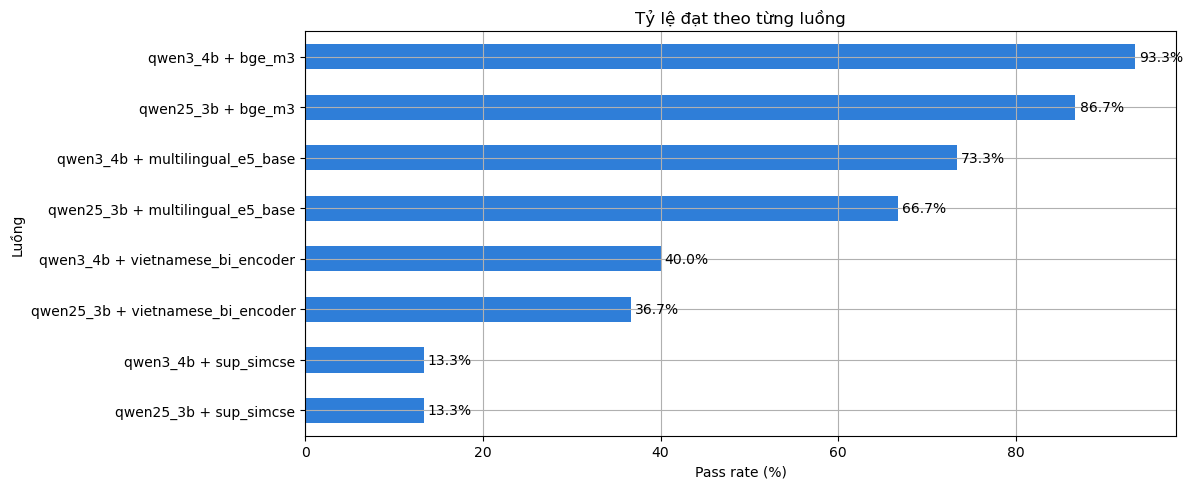

In [4]:
plot_df = summary_df.sort_values('pass_rate')
ax = plot_df.plot.barh(x='pipeline', y='pass_rate_pct', legend=False, color='#2f7ed8')
ax.set_xlabel('Pass rate (%)')
ax.set_ylabel('Luồng')
ax.set_title('Tỷ lệ đạt theo từng luồng')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()


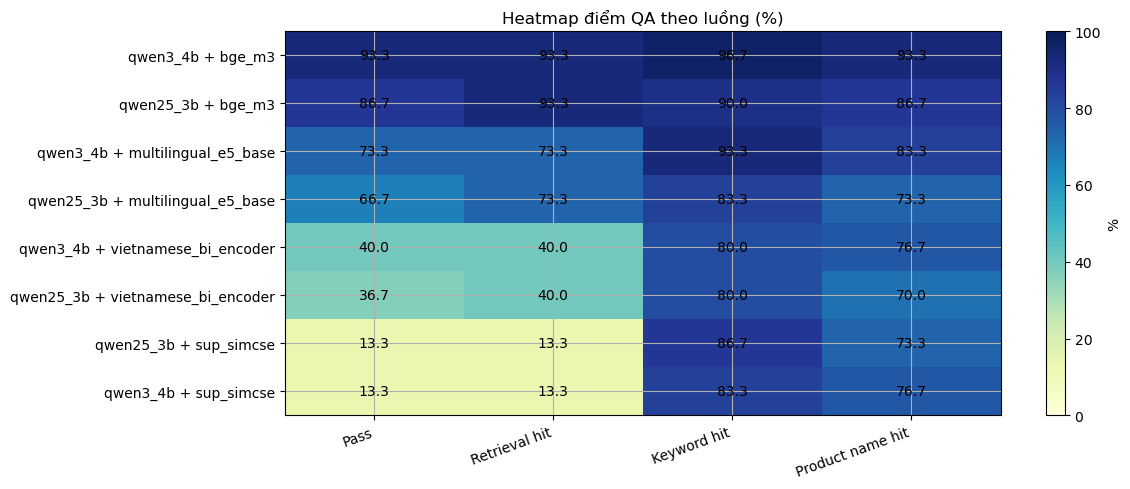

In [5]:
metrics = ['pass_rate_pct', 'retrieval_hit_rate_pct', 'answer_keyword_hit_rate_pct', 'answer_product_name_hit_rate_pct']
metric_labels = ['Pass', 'Retrieval hit', 'Keyword hit', 'Product name hit']
heat_df = summary_df.set_index('pipeline')[metrics].sort_values('pass_rate_pct', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat_df.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax.set_xticks(range(len(metrics)), metric_labels, rotation=20, ha='right')
ax.set_yticks(range(len(heat_df.index)), heat_df.index)
ax.set_title('Heatmap điểm QA theo luồng (%)')
for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        ax.text(j, i, f'{heat_df.iloc[i, j]:.1f}', ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, label='%')
plt.tight_layout()
plt.show()


In [6]:
raw_rows = []
for path in sorted(RESULT_DIR.glob('*.json')):
    if path.name.startswith('eval_'):
        continue
    llm, embedding = parse_pipeline_name(path)
    data = json.loads(path.read_text(encoding='utf-8'))
    for item in data:
        latency = item.get('latency', {})
        raw_rows.append({
            'llm': llm,
            'embedding': embedding,
            'pipeline': f'{llm} + {embedding}',
            'question_id': item.get('question_id'),
            'retrieval_seconds': latency.get('retrieval_seconds'),
            'generation_seconds': latency.get('generation_seconds'),
            'total_seconds': latency.get('total_seconds'),
        })

latency_df = pd.DataFrame(raw_rows)
latency_summary = latency_df.groupby('pipeline', as_index=False).agg(
    avg_retrieval_seconds=('retrieval_seconds', 'mean'),
    avg_generation_seconds=('generation_seconds', 'mean'),
    avg_total_seconds=('total_seconds', 'mean'),
).merge(summary_df[['pipeline', 'pass_rate_pct']], on='pipeline', how='left')

latency_summary = latency_summary.sort_values('avg_total_seconds')
display(latency_summary.round(3))


,pipeline,avg_retrieval_seconds,avg_generation_seconds,avg_total_seconds,pass_rate_pct
2,qwen25_3b + sup_simcse,0.020,8.772,8.791,13.33
3,qwen25_3b + vietnamese_bi_encoder,0.021,8.963,8.984,36.67
1,qwen25_3b + multilingual_e5_base,0.021,10.456,10.478,66.67
0,qwen25_3b + bge_m3,0.051,10.870,10.921,86.67
7,qwen3_4b + vietnamese_bi_encoder,0.022,13.130,13.152,40.00
6,qwen3_4b + sup_simcse,0.041,13.840,13.881,13.33
5,qwen3_4b + multilingual_e5_base,0.020,15.686,15.706,73.33
4,qwen3_4b + bge_m3,0.045,16.364,16.409,93.33


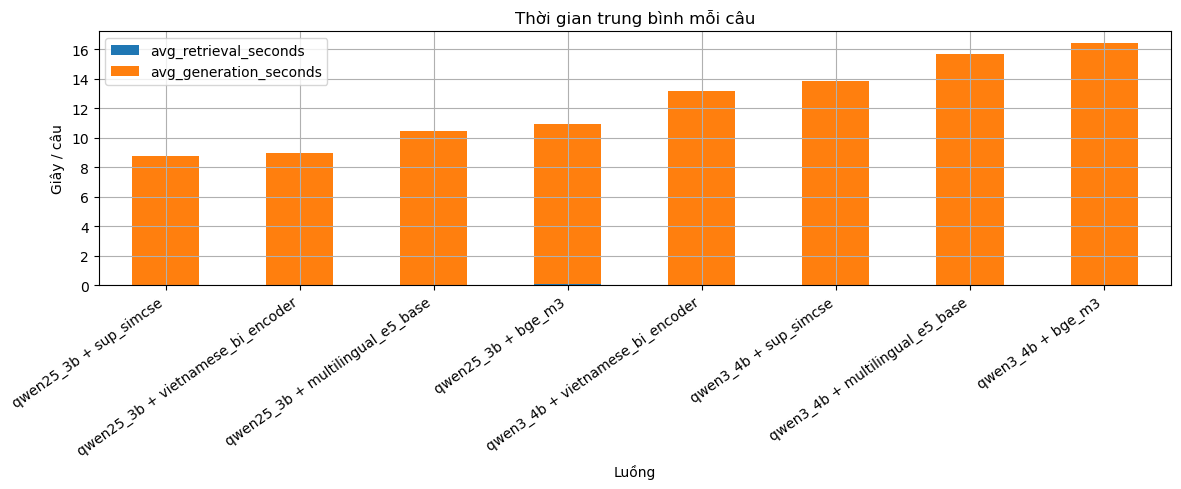

In [7]:
ax = latency_summary.plot.bar(x='pipeline', y=['avg_retrieval_seconds', 'avg_generation_seconds'], stacked=True)
ax.set_ylabel('Giây / câu')
ax.set_xlabel('Luồng')
ax.set_title('Thời gian trung bình mỗi câu')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


In [8]:
eval_items = []
for path in sorted(RESULT_DIR.glob('eval_*.json')):
    report = json.loads(path.read_text(encoding='utf-8'))
    llm, embedding = parse_pipeline_name(path)
    for item in report['items']:
        row = dict(item)
        row['llm'] = llm
        row['embedding'] = embedding
        row['pipeline'] = f'{llm} + {embedding}'
        eval_items.append(row)

items_df = pd.DataFrame(eval_items)

type_summary = (
    items_df.groupby(['pipeline', 'type'], as_index=False)
    .agg(total=('passed', 'size'), passed=('passed', 'sum'))
)
type_summary['pass_rate_pct'] = (type_summary['passed'] / type_summary['total'] * 100).round(2)

display(type_summary.pivot(index='pipeline', columns='type', values='pass_rate_pct').fillna(0).round(2))


type,an_toan,cach_dung,gia,goi_y_san_pham,thanh_phan
pipeline,,,,,
qwen25_3b + bge_m3,83.33,100.00,100.00,66.67,83.33
qwen25_3b + multilingual_e5_base,83.33,100.00,83.33,0.00,66.67
qwen25_3b + sup_simcse,0.00,16.67,33.33,0.00,16.67
qwen25_3b + vietnamese_bi_encoder,33.33,33.33,66.67,0.00,50.00
qwen3_4b + bge_m3,100.00,100.00,100.00,66.67,100.00
qwen3_4b + multilingual_e5_base,83.33,100.00,83.33,16.67,83.33
qwen3_4b + sup_simcse,0.00,16.67,33.33,0.00,16.67
qwen3_4b + vietnamese_bi_encoder,33.33,33.33,66.67,0.00,66.67


In [9]:
failure_summary = (
    items_df[~items_df['passed']]
    .groupby('pipeline', as_index=False)
    .agg(failed=('question_id', 'count'), failed_ids=('question_id', lambda s: ', '.join(s)))
    .sort_values('failed', ascending=False)
)
display(failure_summary)


,pipeline,failed,failed_ids
2,qwen25_3b + sup_simcse,26,"qa001, qa002, qa003, qa005, qa006, qa007, qa009, qa010, qa011, qa014, qa015, qa016, qa017, qa018, qa019, qa020, qa021, qa022, qa023, qa024, qa025, qa026, qa027, qa028, qa029, q..."
6,qwen3_4b + sup_simcse,26,"qa001, qa002, qa003, qa005, qa006, qa007, qa009, qa010, qa011, qa014, qa015, qa016, qa017, qa018, qa019, qa020, qa021, qa022, qa023, qa024, qa025, qa026, qa027, qa028, qa029, q..."
3,qwen25_3b + vietnamese_bi_encoder,19,"qa001, qa002, qa006, qa009, qa010, qa011, qa012, qa014, qa015, qa016, qa017, qa018, qa020, qa021, qa022, qa023, qa026, qa029, qa030"
7,qwen3_4b + vietnamese_bi_encoder,18,"qa001, qa002, qa006, qa010, qa011, qa012, qa014, qa015, qa016, qa017, qa018, qa020, qa021, qa022, qa023, qa026, qa029, qa030"
1,qwen25_3b + multilingual_e5_base,10,"qa001, qa006, qa008, qa009, qa011, qa016, qa019, qa020, qa021, qa026"
5,qwen3_4b + multilingual_e5_base,8,"qa001, qa006, qa008, qa011, qa019, qa020, qa021, qa026"
0,qwen25_3b + bge_m3,4,"qa006, qa009, qa010, qa021"
4,qwen3_4b + bge_m3,2,"qa006, qa021"


In [10]:
# Đổi tên pipeline ở đây để xem chi tiết câu sai của một luồng.
selected_pipeline = summary_df.iloc[0]['pipeline']
print('selected_pipeline =', selected_pipeline)

cols = [
    'question_id', 'type', 'question', 'expected_product_name',
    'retrieval_product_hit', 'answer_keyword_hit', 'answer_product_name_hit', 'passed', 'answer'
]
failed_df = items_df[(items_df['pipeline'] == selected_pipeline) & (~items_df['passed'])][cols]
display(failed_df)


selected_pipeline = qwen3_4b + bge_m3


,question_id,type,question,expected_product_name,retrieval_product_hit,answer_keyword_hit,answer_product_name_hit,passed,answer
125,qa006,goi_y_san_pham,"Rau màu có biểu hiện Rễ ít, đất chai cứng, cây vàng lá sau mưa hoặc sau bón phân mạnh. Nên dùng sản phẩm nào và vì sao?",HUMIC ACID 70%,False,True,False,False,"1. Chẩn đoán khả năng \nRễ ít, đất chai cứng, cây vàng lá sau mưa hoặc sau bón phân mạnh → nguyên nhân có thể do đất nghèo mùn, pH bất lợi, canh tác thâm canh lâu năm, hoặc rễ..."
140,qa021,goi_y_san_pham,"Rau màu có biểu hiện Sinh trưởng chậm, bộ rễ kém, lá xanh không đều. Nên dùng sản phẩm nào và vì sao?",NPK 13-13-13+TE,False,False,False,False,"1. Chẩn đoán khả năng \nBiểu hiện ""Sinh trưởng chậm, bộ rễ kém, lá xanh không đều"" phù hợp với triệu chứng ""lá nhạt màu, cây chậm lớn, ra chồi không đều"" và ""lá xanh nhạt, cây..."


In [11]:
# Xem raw retrieval + answer cho một câu cụ thể.
selected_question_id = failed_df['question_id'].iloc[0] if len(failed_df) else 'qa001'
print('selected_question_id =', selected_question_id)

llm, embedding = selected_pipeline.split(' + ', 1)
raw_path = RESULT_DIR / f'{llm}__{embedding}.json'
raw_data = json.loads(raw_path.read_text(encoding='utf-8'))
raw_item = next(item for item in raw_data if item['question_id'] == selected_question_id)

print('QUESTION:')
print(raw_item['question'])
print('\nANSWER:')
print(raw_item['answer'])
print('\nTOP RETRIEVED CHUNKS:')
for chunk in raw_item['retrieved_chunks'][:5]:
    print(f"rank={chunk['rank']} score={chunk['score']:.4f} product_id={chunk.get('product_id')} ten={chunk.get('ten_san_pham')}")


selected_question_id = qa006
QUESTION:
Rau màu có biểu hiện Rễ ít, đất chai cứng, cây vàng lá sau mưa hoặc sau bón phân mạnh. Nên dùng sản phẩm nào và vì sao?

ANSWER:
1. Chẩn đoán khả năng  
Rễ ít, đất chai cứng, cây vàng lá sau mưa hoặc sau bón phân mạnh → nguyên nhân có thể do đất nghèo mùn, pH bất lợi, canh tác thâm canh lâu năm, hoặc rễ yếu dẫn đến hấp thu dinh dưỡng kém.

2. Sản phẩm gợi ý  
HUMIC RỄ KHỎE 85

3. Lý do phù hợp  
Sản phẩm HUMIC RỄ KHỎE 85 phù hợp vì tập trung xử lý nguyên nhân: đất nghèo mùn, pH bất lợi, canh tác thâm canh lâu năm. Sản phẩm giúp cải tạo đất, kích thích rễ trắng, tăng khả năng giữ phân và giảm hiện tượng chai đất, từ đó cải thiện khả năng hấp thu dinh dưỡng của cây, hỗ trợ cây vàng lá do rễ yếu.

4. Cách dùng tóm tắt  
Tưới 1kg/400-600 lít nước hoặc rải 2-5kg/ha.

5. Lưu ý an toàn  
Không pha với chất oxy hóa mạnh; bảo quản nơi khô ráo.

TOP RETRIEVED CHUNKS:
rank=1 score=0.7256 product_id=sp386 ten=DƯỠNG RAU XANH LÁ
rank=2 score=0.6982 product_id=s

In [12]:
# Xuất bảng tổng hợp ra CSV để dùng trong báo cáo.
out_dir = RESULT_DIR / 'visualization_exports'
out_dir.mkdir(exist_ok=True)
summary_df.to_csv(out_dir / 'pipeline_summary.csv', index=False)
latency_summary.to_csv(out_dir / 'latency_summary.csv', index=False)
type_summary.to_csv(out_dir / 'type_summary.csv', index=False)
items_df.to_csv(out_dir / 'all_eval_items.csv', index=False)
print('Đã xuất CSV vào:', out_dir)


Đã xuất CSV vào: /Users/quangnguyentamhuu/Desktop/Chatbox_ChatBox_BanThuocTruSauNongNghiep/results/generated_qa_30/visualization_exports
